<a href="https://colab.research.google.com/github/joyangelai/Colab-Vol-3/blob/main/Sentiment_Text_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TWEET SENTIMENT ANALYSIS

In [ ]:
#uploading data directly from kaggle
# Create API key
#install kaggle library
#!pip install kaggle


In [ ]:
#configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


Import twitter sentiment dataset api

In [ ]:
#API to fetch the dataset from kaggle
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
sentiment140.zip: Skipping, found more recently modified local copy (use --force to force download)


### from kaggle, get [sentiment](https://www.kaggle.com/datasets/kazanova/sentiment140)

In [ ]:
# #extracting the compresed sentiment dataset
# from zipfile import ZipFile
# file_name = "sentiment140.zip"

# with ZipFile(file_name, 'r') as zip:
#   zip.extractall()
#   print("Done")

Done


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
pd.set_option('display.max_colwidth', None)

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
#check the stopwords
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Data Processing

In [ ]:
#loading the dataset through pandas dataframe
df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1')

#Print the first 5 rows
df.head()


,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1.467811e+09,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
1,0,1.467811e+09,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
2,0,1.467811e+09,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1.467811e+09,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."
4,0,1.467811e+09,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
#check the number of rows and columns
df.shape

(21123, 6)

dataset contains the following 6 fields:

* target: the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)

* ids: The id of the tweet ( 2087)

* date: the date of the tweet (Sat May 16 23:58:44 UTC 2009)

* flag: The query (lyx). If there is no query, then this value is NO_QUERY.

* user: the user that tweeted (robotickilldozr)

* tweet: the text of the tweet (Lyx is cool)

In [ ]:
#Name the columns
columns_name = ['target', 'id', 'date', 'flag', 'user', 'tweet']
#Reload the dataset with column name
twitter_data= pd.read_csv('training.1600000.processed.noemoticon.csv', names= columns_name, encoding='ISO-8859-1')

#check the top 5 rows
twitter_data.head()

,target,id,date,flag,user,tweet
0,0,1.467810e+09,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1.467811e+09,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1.467811e+09,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1.467811e+09,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1.467811e+09,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


In [ ]:
#check number of rows and columns
twitter_data.shape

(21124, 6)

Data cleaning

In [ ]:
#check missing values
twitter_data.isnull().sum()

,0
target,0
id,1
date,1
flag,1
user,1
tweet,1


target
0    21124
Name: count, dtype: int64


TypeError: object of type 'float' has no len()

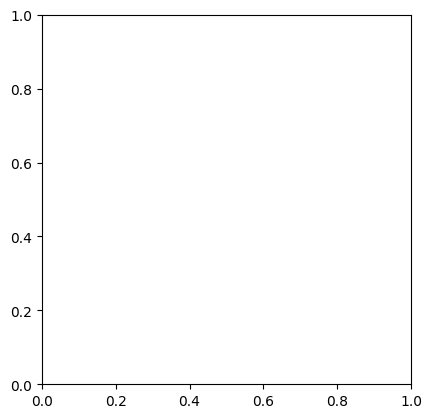

In [ ]:
#check distribution of the target variable
#twitter_data['target'].value_counts().plot(kind='pie', labels = ["Negative", "Positive"], autopct='%.2f')
target_count = twitter_data.target.value_counts()
print(target_count)
plt.pie(target_count, labels = target_count.index, autopct='%.2f', startangle=45, explode=(0.05 *len(target_count)))
plt.title("Target Distribution")
plt.show()

In [ ]:
#Check the atrget
twitter_data['target'].value_counts()

,count
target,
0,21124


In [ ]:
#replace 4 with 1
twitter_data.loc[twitter_data['target'] == 4, 'target'] = 1

# or
#twitter_data.replace({'target':{4:1}}, inplace =True)

#or
#use replace method
#twitter_data["target"].replace(4, 1, inplace=True)

twitter_data.target.value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

0 ---> Negative tweet

1 ---> Positive tweet

Observation: the positive and negative tweets are the same, fix the to balance incase of class imbalance.

#Since the dataset is huge, i will just take a sample of it

In [ ]:
'''
#take 4000 from each class
negative_tweets = twitter_data[twitter_data['target'] == 0].sample(4000)
positive_tweets = twitter_data[twitter_data['target'] == 1].sample(4000)

#concat
twitter_data = pd.concat([negative_tweets, positive_tweets], axis=0)

#check the shape
twitter_data.shape
'''

"\n#take 4000 from each class\nnegative_tweets = twitter_data[twitter_data['target'] == 0].sample(4000)\npositive_tweets = twitter_data[twitter_data['target'] == 1].sample(4000)\n\n#concat\ntwitter_data = pd.concat([negative_tweets, positive_tweets], axis=0)\n\n#check the shape\ntwitter_data.shape\n"

In [ ]:
#drop unnessary columns
twitter_data = twitter_data.drop(['id', 'date', 'flag', 'user'], axis=1)
twitter_data.head()

,target,tweet
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


### Stemming

This is the process of reducing a word to it's root word

example: actor, actress, acting = act



In [ ]:
#stemming
ps = PorterStemmer()

#create a function
def stemming(content):

    #use regex
    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
   #convert the text to lower case
    stemmed_content = stemmed_content.lower()
    #tokenize the text
    stemmed_content = stemmed_content.split()
    #apply stemming
    stemmed_content = [ps.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    #join the stemmed words
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

In [ ]:
#apply the tweet to the function
twitter_data['stemmed_tweets'] = twitter_data['tweet'].apply(stemming)
twitter_data.head()


,target,tweet,stemmed_tweets
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",switchfoot http twitpic com zl awww bummer shoulda got david carr third day
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,upset updat facebook text might cri result school today also blah
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,kenichan dive mani time ball manag save rest go bound
3,0,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",nationwideclass behav mad see


EDA

In [ ]:
#Get positve tweets
all_posit_words = ' '.join([text for text in twitter_data['stemmed_tweets'][twitter_data['target'] == 1]])

#Get negative tweets
all_neg_words = ' '.join([text for text in twitter_data['stemmed_tweets'][twitter_data['target'] == 0]])


(-0.5, 799.5, 499.5, -0.5)

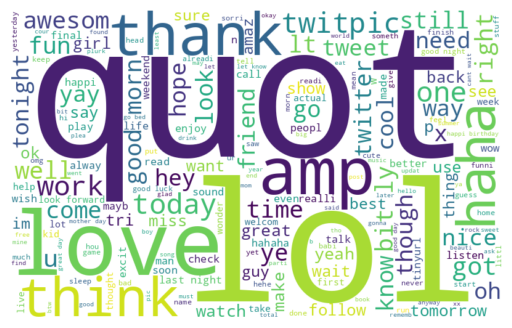

In [ ]:
#create word cloud for positive tweets
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=500,
                      background_color='white',
                      min_font_size=10).generate(all_posit_words)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

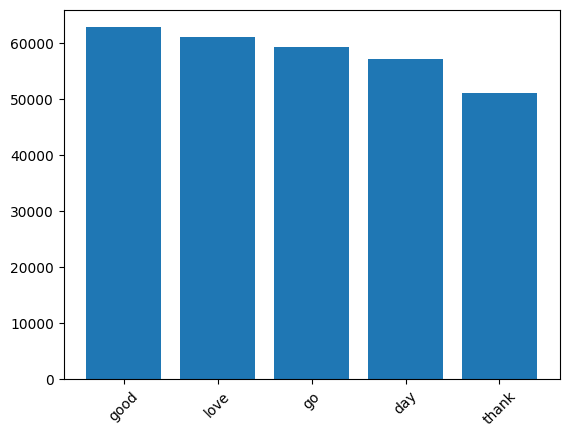

In [ ]:
#top 5 positive tweets
#get top five words
from collections import Counter
positive_words = Counter(all_posit_words.split())

#plot
positive_words = pd.DataFrame(positive_words.most_common(5), columns=['word', 'count'])
positive_words
plt.bar(positive_words['word'], positive_words['count'])
plt.xticks(rotation=45)
plt.show()

(-0.5, 799.5, 499.5, -0.5)

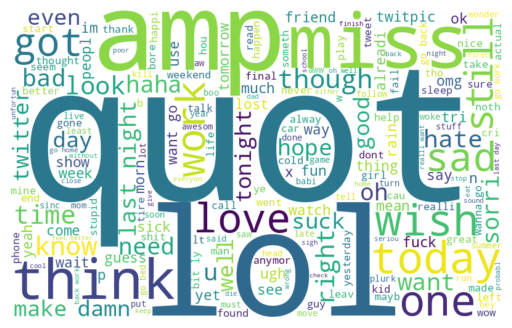

In [ ]:
#word cloud for negative tweets
wordcloud = WordCloud(width=800, height=500,
                      background_color='white',
                      min_font_size=10).generate(all_neg_words)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

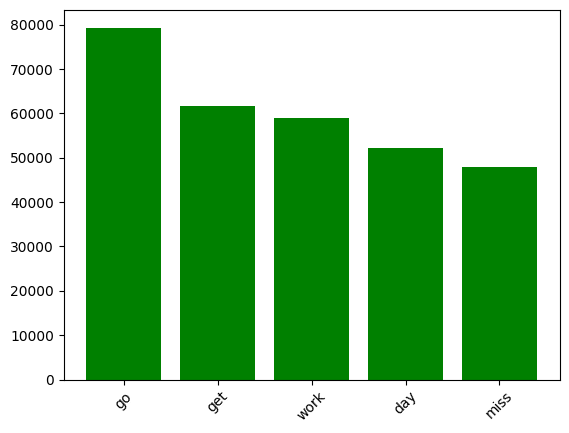

In [ ]:
#top 5 Negative tweets
#get  five negative words
from collections import Counter
negative_tweets = Counter(all_neg_words.split())

#plot
negative_words = pd.DataFrame(negative_tweets.most_common(5), columns=['word', 'count'])
plt.bar(negative_words['word'], negative_words['count'], color='g')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Separate target and feature variable
X = twitter_data['stemmed_tweets'].values
Y = twitter_data['target'].values

In [ ]:
#Print X
print(X)

['switchfoot http twitpic com zl awww bummer shoulda got david carr third day'
 'upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound' ...
 'readi mojo makeov ask detail'
 'happi th birthday boo alll time tupac amaru shakur'
 'happi charitytuesday thenspcc sparkschar speakinguph h']


In [ ]:
#Print(y)
print(Y)

[0 0 0 ... 1 1 1]


## Split the data to train and test data

In [ ]:
#split data to train and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [ ]:
#print the shape to check the split propotion
print(X.shape, X_train.shape, X_test.shape)

(1600000,) (1280000,) (320000,)


## Convert textual data to numerical data

In [ ]:
#convert using tfidf
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
#print xtrain
print(X_train)

  (0, 443066)	0.4484755317023172
  (0, 235045)	0.41996827700291095
  (0, 109306)	0.3753708587402299
  (0, 185193)	0.5277679060576009
  (0, 354543)	0.3588091611460021
  (0, 436713)	0.27259876264838384
  (1, 160636)	1.0
  (2, 288470)	0.16786949597862733
  (2, 132311)	0.2028971570399794
  (2, 150715)	0.18803850583207948
  (2, 178061)	0.1619010109445149
  (2, 409143)	0.15169282335109835
  (2, 266729)	0.24123230668976975
  (2, 443430)	0.3348599670252845
  (2, 77929)	0.31284080750346344
  (2, 433560)	0.3296595898028565
  (2, 406399)	0.32105459490875526
  (2, 129411)	0.29074192727957143
  (2, 407301)	0.18709338684973031
  (2, 124484)	0.1892155960801415
  (2, 109306)	0.4591176413728317
  (3, 172421)	0.37464146922154384
  (3, 411528)	0.27089772444087873
  (3, 388626)	0.3940776331458846
  (3, 56476)	0.5200465453608686
  :	:
  (1279996, 390130)	0.22064742191076112
  (1279996, 434014)	0.2718945052332447
  (1279996, 318303)	0.21254698865277746
  (1279996, 237899)	0.2236567560099234
  (1279996, 2910

In [ ]:
#print ytain
print(Y_train)

[1 1 0 ... 1 1 0]


## Training the ML

In [ ]:
#use logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation using accuracy score and confusion matrix

In [ ]:
#evaluate the model
X_train_prediction = lr.predict(X_train)
training_accuracy = accuracy_score(X_train_prediction, Y_train)

#print accuracy
print('Accuracy on training data : ', round(training_accuracy*100, 2))

Accuracy on training data :  81.02


In [ ]:
#check the test accuracy
X_test_prediction = lr.predict(X_test)
test_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy on test data : ', round(test_accuracy*100,2))

NameError: name 'lr' is not defined

Observation: the model is performing well.

In [ ]:
#check confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test, X_test_prediction)


array([[121445,  38555],
       [ 32473, 127527]])

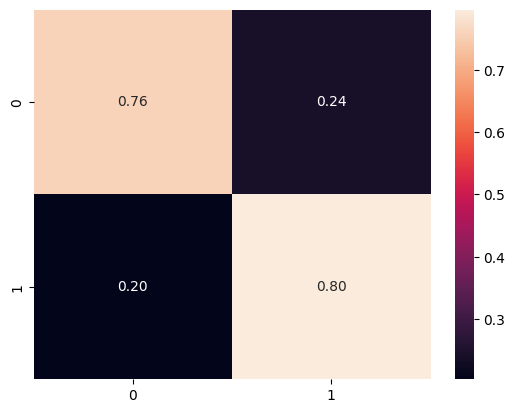

In [ ]:
#visualize confusion matrix
import seaborn as sns
cm = confusion_matrix(Y_test, X_test_prediction, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f')
plt.show()

In [ ]:
#check classification report
from sklearn.metrics import classification_report
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           1       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



In [ ]:
# Check roc
fpr, tpr, thresholds = roc_curve(Y_test, X_test_prediction)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

AUC: 0.7780375000000002


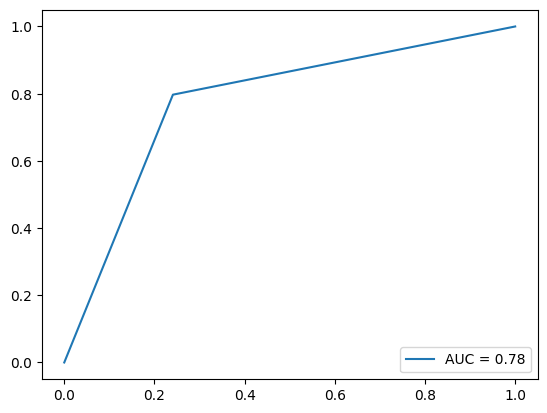

In [ ]:
#visualize AUC
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')

## Do hyperameter tuning of the model using gridsearch

#save the best model in pickle

In [ ]:
#save the model in pickle
import pickle
filename = 'finalized_sentiment_model.sav'
pickle.dump(lr, open(filename, 'wb'))

### using the saved model for future prediction

In [ ]:
#load the saved model
loaded_model = pickle.load(open('/content/finalized_sentiment_model.sav', 'rb'))

In [ ]:
#use the new dataset to do prediction
x_new = X_test[3]
print(Y_test[3])

#create a function for prediction
prediction = lr.predict(x_new)
print(prediction)

if prediction[0] == 0:
    print('Negative')
elif prediction[0] == 1:
    print('Positive')

0
[0]
Negative


END